In [24]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [25]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [26]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [27]:
len(words)

32033

In [28]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [29]:
# build dataset
block_size = 3

def build_dataset(words):
    X, Y = [], []
    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

In [30]:
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [31]:
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),           generator=g)
W1 = torch.randn(n_embd * block_size, n_hidden, generator=g) * (5/3) / ((block_size * n_embd) **0.5) # Tanh non-linearity Gain
# b1 = torch.randn(n_hidden,                      generator=g) * 0.01
W2 = torch.randn(n_hidden, vocab_size,          generator=g) * 0.01
b2 = torch.randn(vocab_size,                    generator=g) * 0

    
bngain = torch.ones((1, n_hidden)) # BN scaling 
bnbias = torch.zeros((1, n_hidden)) # BN shifting
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1 ,W2, b2, bngain, bnbias]
sum(p.nelement() for p in parameters)
for p in parameters:
    p.requires_grad = True



In [33]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]


    # forward pass
    emb = C[Xb] # embedding
    embcat = emb.view(emb.shape[0], -1) # vector concatenation
    # Linear Layer
    hpreact = embcat @ W1# + b1          # hidden layer pre-activation

    # BATCH NORM LAYER
    # --------------------------------------------------------------------------------
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias # Batch Normalization

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    
    # --------------------------------------------------------------------------------

    # Non-linearity
    h = torch.tanh(hpreact)             # hidden layer
    logits = h @ W2 + b2                # output layer
    loss = F.cross_entropy(logits, Yb)  # loss function


    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    if i % 10000 == 0:
        print(f'{i:7d} / {max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    break

      0 /  200000: 2.3013


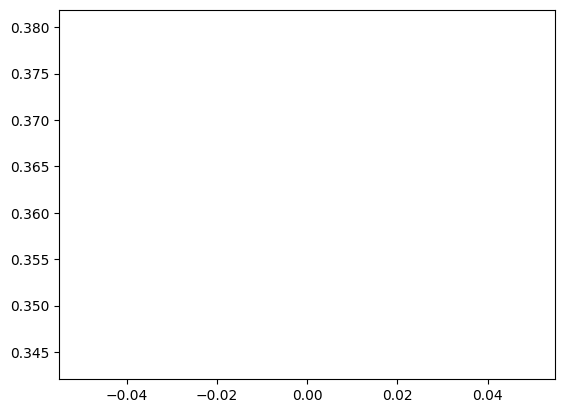

In [34]:
plt.plot(lossi)

In [35]:
# Calibrate the batch norm at the end of the training

with torch.no_grad():
    # Pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    # hpreact = embcat @ W1 + b1

    #measure the mean/std over the entire training set
    bnmean = hpreact.mean(0 ,keepdim=True)
    bnstd = hpreact.std(0 ,keepdim=True)

    

`bnmean` stores the calibrated mean of the hidden pre-activations over the entire training set.

`bnbias` is the learned batch-norm bias term used to shift the normalized activations.

In evaluation:
- subtract `bnmean` from `hpreact`
- divide by `bnstd`
- scale by `bngain`
- add `bnbias`

This ensures the same normalization used during training is applied at inference time, with `bnbias` providing the final learned shift.

In [36]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 #+ b1
    hpreact = bngain * (hpreact - bnmean_running)/ bnstd_running + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')
    

train 2.244999885559082
val 2.2565248012542725


# PyTorch-ifying the code

In [42]:
#fan_in = no. of inputs
#fan_out = no. of outputs

class Linear:
    def __init__(self, fan_in, fan_out, device = device, bias = True):
        self.weight = torch.randn((fan_in, fan_out), generator = g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
    def __init__(self, dim, eps = 1e-5, momentum = 0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # Parameters (Trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # Calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim = True) # batch mean
            xvar = x.var(0, keepdim = True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalise to unit variance
        self.out = self.gamma * xhat + self.beta

        #update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self,x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of MLP
f = torch.Generator().manual_seed(2147483647) 

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
]

with torch.no_grad():
    # last layer: make less confident
    layers[-1].weight *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3 # Gain is set to 1 when there are no non-linearities like tanh

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

46497


In [43]:
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    #minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    #forward pass
    emb = C[Xb] # embed the characters into vectors
    x = emb.view(emb.shape[0], -1) # concatenate the vectors
    for layer in layers: 
        x = layer(x)
    loss = F.cross_entropy(x, Yb) # loss function   

    #backward pass
    for layer in layers:
        layer.out.retain_grad() # AFTER DEBUG: would take out retain graph
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    if i % 10000 == 0: #prints progress of training
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append([(lr * p.grad.std() / p.data.std()).log10().item() for p in parameters])

    if i > 1000:
        break # Only for testing



      0/ 200000: 3.3007


layer 1 (      Tanh): mean +0.03, std 0.76, saturated 21.47%
layer 3 (      Tanh): mean -0.02, std 0.71, saturated 12.28%
layer 5 (      Tanh): mean +0.05, std 0.71, saturated 11.41%
layer 7 (      Tanh): mean -0.09, std 0.72, saturated 11.81%
layer 9 (      Tanh): mean -0.05, std 0.71, saturated 11.09%


Text(0.5, 1.0, 'Activation Distribution')

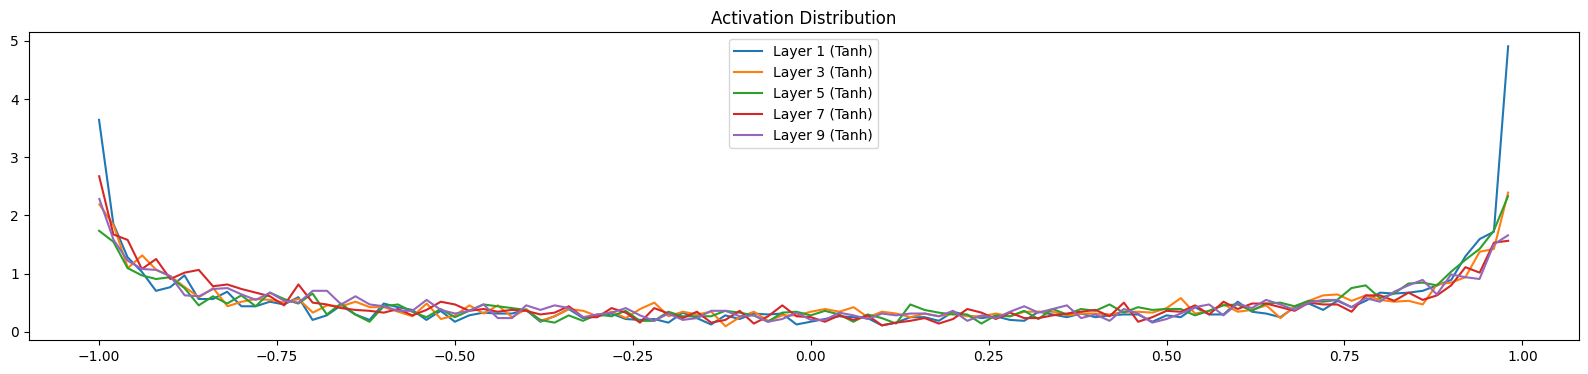

In [44]:
# Forward Pass Activation Statistics (visualise histograms)
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]): # exclude the output layer
    if isinstance(layer, Tanh): # Using tanh layer as it gives finite value between -1 and 1 which makes it easier to visualise
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'Layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('Activation Distribution')

layer 1 (      Tanh): mean +0.00, std 3.041469e-03
layer 3 (      Tanh): mean +0.00, std 2.784877e-03
layer 5 (      Tanh): mean +0.00, std 2.739450e-03
layer 7 (      Tanh): mean +0.00, std 2.648005e-03
layer 9 (      Tanh): mean -0.00, std 2.099541e-03


Text(0.5, 1.0, 'Gradient Distribution')

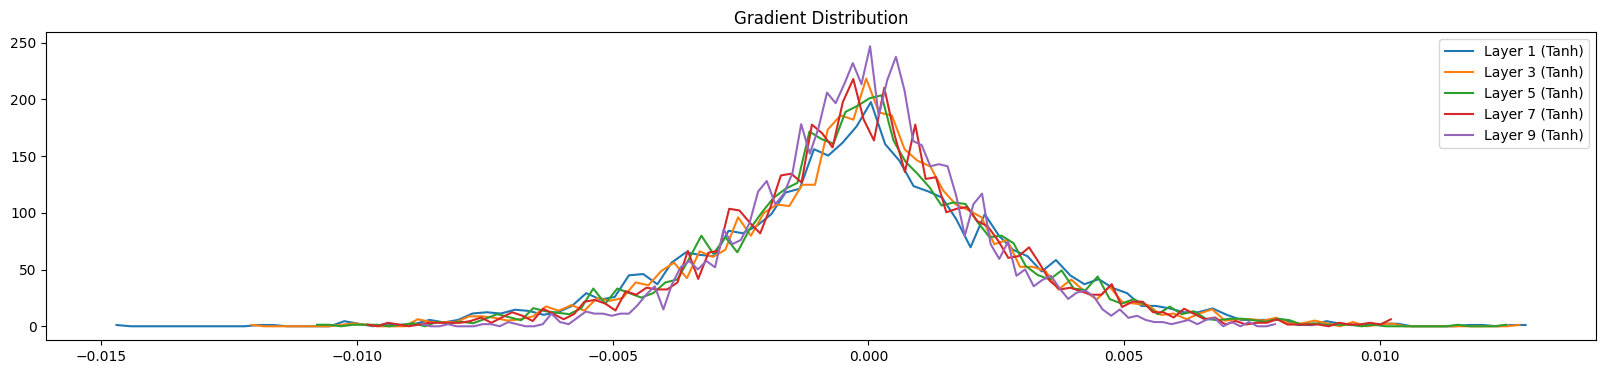

In [45]:
# Backward Psss Gradient Statistics (visualise histograms)
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]): # exclude the output layer
    if isinstance(layer, Tanh): # Using tanh layer as it gives finite value between -1 and 1 which makes it easier to visualise
        t = layer.out.grad
        print('layer %d (%10s): mean %+.2f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'Layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('Gradient Distribution')

weight   (27, 10) | mean -0.00 | std 9.980390e-03 | grad:data ratio 1.035770e-02
weight  (30, 100) | mean -0.00 | std 9.430697e-03 | grad:data ratio 3.108523e-02
weight (100, 100) | mean +0.00 | std 7.492104e-03 | grad:data ratio 4.435530e-02
weight (100, 100) | mean -0.00 | std 6.405998e-03 | grad:data ratio 3.834717e-02
weight (100, 100) | mean -0.00 | std 5.809589e-03 | grad:data ratio 3.427139e-02
weight (100, 100) | mean -0.00 | std 4.941672e-03 | grad:data ratio 2.952381e-02
weight  (100, 27) | mean +0.00 | std 1.989333e-02 | grad:data ratio 2.870134e-01


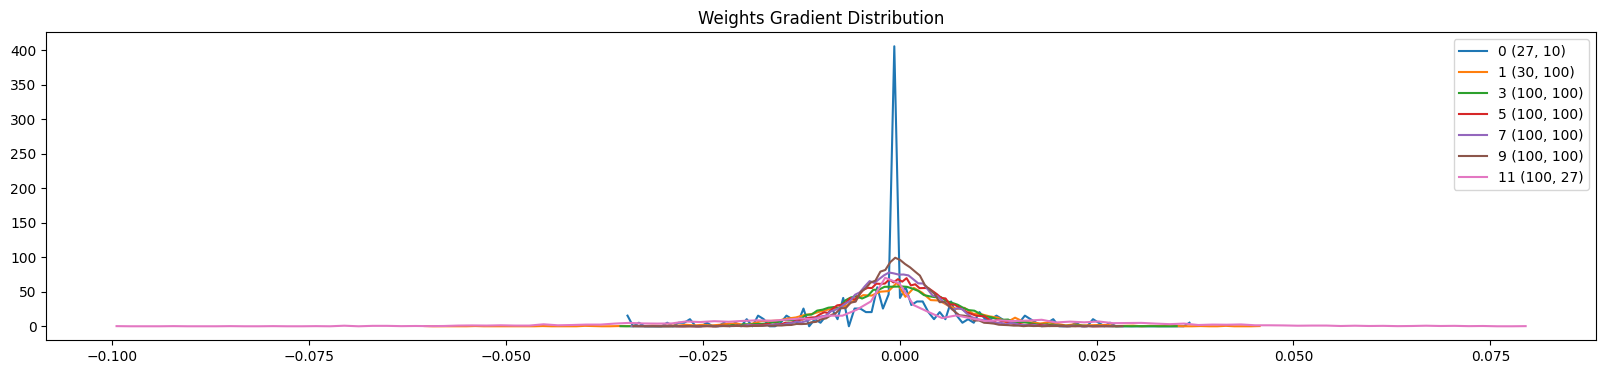

In [46]:
# Parameter Activations and Gradient Statistics (visualise histograms)
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weight %10s | mean %+.2f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('Weights Gradient Distribution');

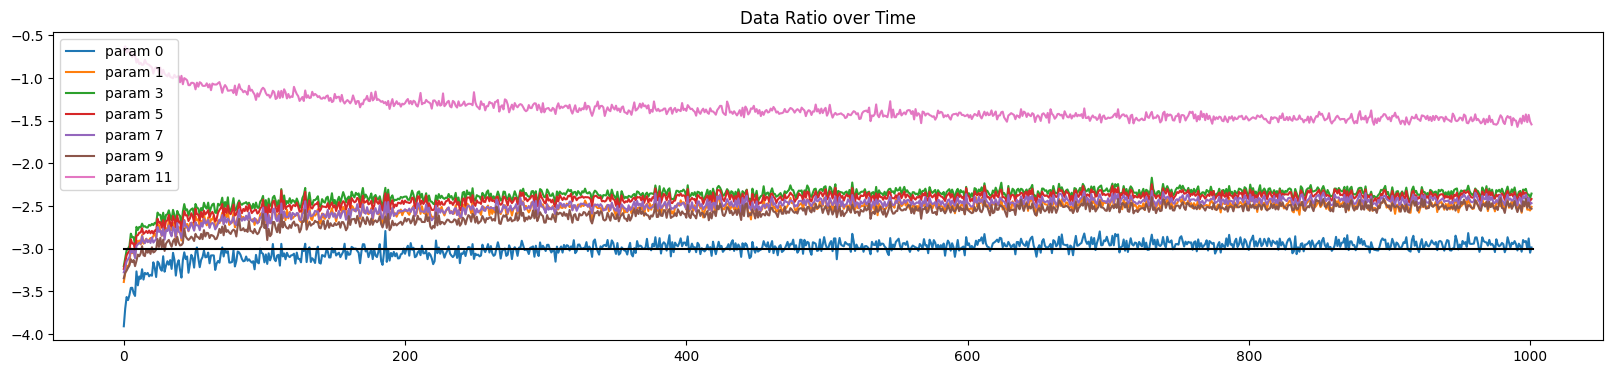

In [47]:
# Data Ratio over time (visualise histograms)
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # These ratios should be ~1e-3, indicate on plot
plt.legend(legends)
plt.title('Data Ratio over Time');